# ERA5 Zarr Archive Analysis and Visualization 1: Maps

## Overview
1. Work with a cloud-served ERA5 archive
2. Subset the Dataset along its dimensions
3. Perform unit conversions
4. Create a well-labeled multi-parameter contour plot of gridded ERA5 data

<div class="alert alert-info"><b>Interactive work with your group</b> Complete any code lines that do not have anything after the <code>=</code> sign or are replaced by a <code>?</code>, or otherwise asks you to complete the code cell.</div>


## Imports

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
from datetime import datetime as dt
from metpy.units import units
import metpy.calc as mpcalc
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

## Select the region, time, and (if applicable) vertical level(s) of interest.

In [2]:
# Areal extent

lonW = -94
lonE = -85
latS = 27
latN = 33
cLat, cLon = (latS + latN)/2, (lonW + lonE)/2

# Recall that in ERA5, longitudes run between 0 and 360, not -180 and 180
if (lonW < 0 ):
    lonW = lonW + 360
if (lonE < 0 ):
    lonE = lonE + 360
    
expand = 1
latRange = np.arange(latS - expand,latN + expand,.25) # expand the data range a bit beyond the plot range
lonRange = np.arange((lonW - expand),(lonE + expand),.25) # Need to match longitude values to those of the coordinate variable

# Vertical level specificaton
plevel = 500
levelStr = str(plevel)

# Date/Time specification
Year = 2021
Month = 8
Day = 29
Hour = 17
Minute = 0
dateTime = dt(Year,Month,Day,Hour)
timeStr = dateTime.strftime("%Y-%m-%d %H%M UTC")
timeStr

'2021-08-29 1700 UTC'

## Work with a cloud-served ERA5 archive

Parts of the [ECMWF Reanalysis version 5](https://www.ecmwf.int/en/forecasts/dataset/ecmwf-reanalysis-v5) (aka **ERA-5**) are increasingly accessible via a [Analysis Ready, Cloud Optimized](https://www.frontiersin.org/articles/10.3389/fclim.2021.782909/full) (aka **ARCO**) format.

We will utilize [Destination Earth's Earth Data Hub](https://earthdatahub.destine.eu/) (*Free account required*) as our primary ERA5 repository. Another one, which we will fall back on should the primary be inaccessible, is [WeatherBench2](https://weatherbench2.readthedocs.io/en/latest/).


### Open an object that points to one of the two Zarr stores.

In [3]:
%%time 
use_DE = True
#use_DE = False
if (use_DE):
  ds = xr.open_dataset(
  'https://data.earthdatahub.destine.eu/era5/reanalysis-era5-pressure-levels-v0.zarr', 
  chunks={}, storage_options={"client_kwargs":{"trust_env":True}}, consolidated=True, engine="zarr"
  )

else:
    ds = xr.open_dataset(
    'gs://weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721.zarr', 
     chunks = {'time':48}, consolidated = True, engine="zarr"
    )
print(f'size: {ds.nbytes / (1024 ** 4)} TB')

size: 863.9610183753794 TB
CPU times: user 1.35 s, sys: 247 ms, total: 1.6 s
Wall time: 4.29 s


The cloud-hosted datasets are **big** (800+TB and 40+TB) files! But Xarray is just reading only enough of the file for us to get a look at the dimensions, coordinate and data variables, and other metadata. We call this *lazy loading*, as opposed to *eager loading*, which we will do only after we have subset the dataset over time, lat-lon, and vertical level.

### Examine the dataset

In [4]:
# Write your code here
ds

<xarray.Dataset> Size: 950TB
Dimensions:        (valid_time: 752424, isobaricInhPa: 19, latitude: 721,
                    longitude: 1440)
Coordinates:
  * valid_time     (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2025-10-31T...
  * isobaricInhPa  (isobaricInhPa) int32 76B 1000 925 850 700 600 ... 20 10 5 1
  * latitude       (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude      (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    number         int64 8B ...
Data variables: (12/16)
    cc             (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    ciwc           (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    clwc           (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    crwc           (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    cswc           (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    d              (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    ...             ...
    t              (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    u              (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    v              (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    vo             (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    w              (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    z              (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-11-15T16:05 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

<div class="alert alert-warning"><b>Explore the HTML-friendly representation of the dataset!</b> Pay attention to the names of dimensions, coordinate variables, and data variables!
</div>

### Data variables selection and subsetting
We'll retrieve one variable (i.e. `DataArray`), **geopotential**, from the `Dataset`. Examine it after performing the subsetting.

In [5]:
%%time 
if (use_DE):
    z = ds['z'].sel(valid_time=dateTime,isobaricInhPa=plevel,latitude=latRange,longitude=lonRange)
else:
    z = ds['geopotential'].sel(time=dateTime,level=plevel,latitude=latRange,longitude=lonRange)

z

CPU times: user 4.75 s, sys: 501 ms, total: 5.25 s
Wall time: 5.27 s


<xarray.DataArray 'z' (latitude: 32, longitude: 44)> Size: 6kB
dask.array<getitem, shape=(32, 44), dtype=float32, chunksize=(32, 44), chunktype=numpy.ndarray>
Coordinates:
  * latitude       (latitude) float64 256B 26.0 26.25 26.5 ... 33.25 33.5 33.75
  * longitude      (longitude) float64 352B 265.0 265.2 265.5 ... 275.5 275.8
    isobaricInhPa  int32 4B 500
    number         int64 8B ...
    valid_time     datetime64[ns] 8B 2021-08-29T17:00:00
Attributes: (12/31)
    GRIB_NV:                                  0
    GRIB_Nx:                                  1440
    GRIB_Ny:                                  721
    GRIB_cfName:                              geopotential
    GRIB_cfVarName:                           z
    GRIB_dataType:                            an
    ...                                       ...
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_units:                               m**2 s**-2
    GRIB_uvRelativeToGrid:                    0
    long_name:                                Geopotential
    standard_name:                            geopotential
    units:                                    m**2 s**-2

#### Define our subsetted coordinate arrays of lat and lon. Pull them from the DataArray. We'll need to pass these into the contouring functions later on.

In [6]:
lats = z.latitude
lons = z.longitude

## Perform unit conversions

Convert geopotential in `m**2/s**2` to geopotential height in decameters (`dam`).

We take the DataArrays and apply [MetPy's unit conversion methods](https://unidata.github.io/MetPy/latest/tutorials/xarray_tutorial.html#units).

In [7]:
z = mpcalc.geopotential_to_height(z).metpy.convert_units('dam')

In [8]:
z

<xarray.DataArray 'truediv-d6a5380bfef3c16aff85ac00ff57ee1b' (latitude: 32,
                                                              longitude: 44)> Size: 6kB
<Quantity(dask.array<mul, shape=(32, 44), dtype=float32, chunksize=(32, 44), chunktype=numpy.ndarray>, 'decameter')>
Coordinates:
  * latitude       (latitude) float64 256B 26.0 26.25 26.5 ... 33.25 33.5 33.75
  * longitude      (longitude) float64 352B 265.0 265.2 265.5 ... 275.5 275.8
    isobaricInhPa  int32 4B 500
    number         int64 8B ...
    valid_time     datetime64[ns] 8B 2021-08-29T17:00:00

<div class="alert alert-warning">These conversions involve actual calculations, so in that cell, we are not *lazy-loading*. But that is the first instance where actual bytes of anything other than metadata get transfered ... <i>and we've already subset our original much larger datsets into something much smaller</i>.
</div>

In [9]:
z.nbytes / 1e3 # size in KB for the subsetted DataArrays

5.632

## Create a well-labeled multi-parameter contour plot of gridded ERA5 reanalysis data

We will make contour fills of 500 hPa height in decameters, with a contour interval of 6 dam.

As we've done before, let's first define some variables relevant to Cartopy. Recall that we already defined the areal extent up above when we did the data subsetting.

In [10]:
proj_map = ccrs.LambertConformal(central_longitude=90, central_latitude=30)
proj_data = ccrs.PlateCarree() # Our data is lat-lon; thus its native projection is Plate Carree.
res = '50m'

#### Now define the range of our contour values and a contour interval. 60 m is standard for 500 hPa. Here, we are using decameters, not meters, so assign the correct value for the contour interval.

In [11]:
minVal = 474
maxVal = 606
cint = 6
Zcintervals = np.arange(minVal, maxVal, cint)
Zcintervals

array([474, 480, 486, 492, 498, 504, 510, 516, 522, 528, 534, 540, 546,
       552, 558, 564, 570, 576, 582, 588, 594, 600])

### Plot the map, with line contours of 500 hPa geopotential height.

Create a meaningful title string.

In [12]:
tl1 = f"ERA5 {levelStr} hPa heights (dam, contour lines)"
tl2 = f"Valid at: {timeStr}"
title_line = (tl1 + '\n' + tl2 + '\n')

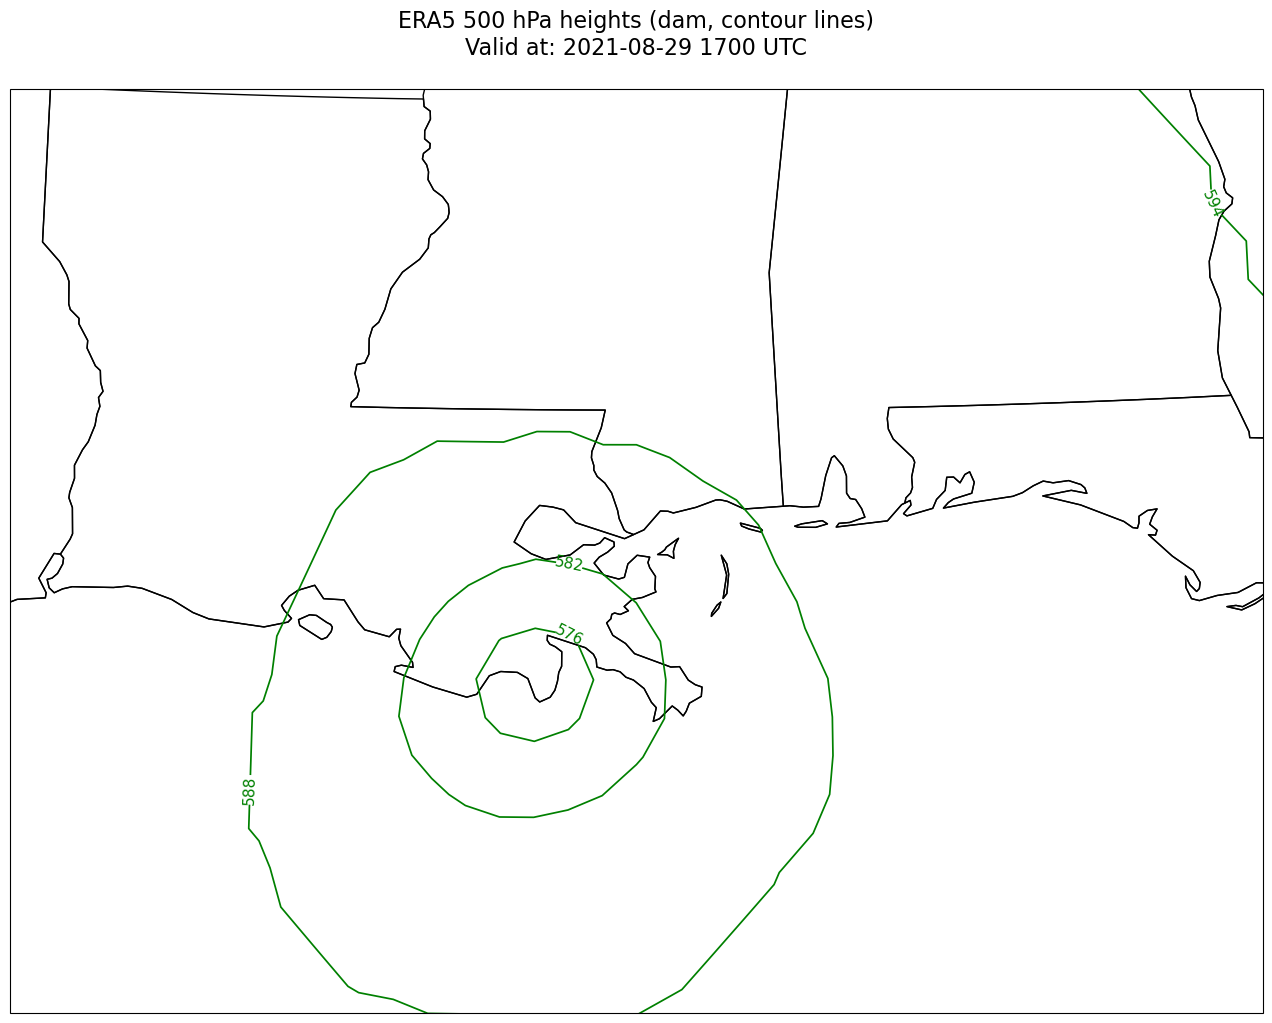

In [13]:
proj_map = ccrs.LambertConformal(central_longitude=cLon, central_latitude=cLat)
proj_data = ccrs.PlateCarree()
res = '50m'
fig = plt.figure(figsize=(18,12))
ax = plt.subplot(1,1,1,projection=proj_map)
ax.set_extent ([lonW,lonE,latS,latN])
ax.add_feature(cfeature.COASTLINE.with_scale(res))
ax.add_feature(cfeature.STATES.with_scale(res))
CL = ax.contour(lons, lats, z, levels=Zcintervals,transform=proj_data,linewidths=1.25, colors='green')
ax.clabel(CL, inline_spacing=0.2, fontsize=11, fmt='%.0f')
title = plt.title(title_line,fontsize=16)

### Eliminate the blank areas, increasingly visible at higher latitudes, at the western and eastern edges of the map (this occurs because the native resolution of the dataset is lat-lon, while the displayed projection is Lambert Conformal).